# PART A: Dataset Analysis

In [1]:
#!rm -rf /kaggle/working/*

## INPUT FILES — Painter by Numbers Dataset

### all_data_info.csv
- Includes artist,date,genre,pixelsx,pixelsy,size_bytes,source,style,title,artist_group,in_train,new_filename
- artist_group field says if data is present only in train/test/in both

### replacements_for_corrupted_files.zip
- Contains the replacements for corrupted data
- 3 in test and 7 in train , total 10 to be replaced

### test.zip
- Images in the test set.

### train.zip
- Images in the train set.

### train_1.zip to train_9.zip
- subsets of train.zip.
- Dataset is split into multiple ZIPs to make downloading and processing easier.

### train_info.csv
- Metadata for training images.
- Includes filename,artist,title,style,genre,date.

## Importing All modules

In [2]:
# ===============================
# Standard Library Imports
# ===============================
import itertools
import os
import re
import shutil
import time
import zipfile
from datetime import datetime

# ===============================
# Utility & Progress Tracking
# ===============================
from tqdm import tqdm

# ===============================
# Data Handling & Numerical
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualization
# ===============================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
matplotlib.rc_file_defaults()

# ===============================
# Image Processing
# ===============================
import cv2
from PIL import Image
from skimage.feature import hog

# ===============================
# Scikit-learn
# ===============================
from sklearn import preprocessing, svm
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import (
    cross_val_score,
    train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ===============================
# PyTorch
# ===============================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import models, transforms

## Loading data

In [3]:
path = '../input/painter-by-numbers/'
df = pd.read_csv(path+'all_data_info.csv')
df.head()

,artist,date,genre,pixelsx,pixelsy,size_bytes,source,style,title,artist_group,in_train,new_filename
0,Barnett Newman,1955.0,abstract,15530.0,6911.0,9201912.0,wikiart,Color Field Painting,Uriel,train_only,True,102257.jpg
1,Barnett Newman,1950.0,abstract,14559.0,6866.0,8867532.0,wikiart,Color Field Painting,Vir Heroicus Sublimis,train_only,True,75232.jpg
2,kiri nichol,2013.0,NaN,9003.0,9004.0,1756681.0,NaN,Neoplasticism,NaN,test_only,False,32145.jpg
3,kiri nichol,2013.0,NaN,9003.0,9004.0,1942046.0,NaN,Neoplasticism,NaN,test_only,False,20304.jpg
4,kiri nichol,2013.0,NaN,9003.0,9004.0,1526212.0,NaN,Neoplasticism,NaN,test_only,False,836.jpg


### Dataset details

In [4]:
print(f"The full dataset contains a total of {len(df['artist'].unique())} different artists and {len(df['genre'].unique())} unique painting genres.\n")
print(f"Total images: {len(df)}")

The full dataset contains a total of 2319 different artists and 43 unique painting genres.

Total images: 103250


# Data Cleaning :
## Corrupted Image Replacement

**What this code does:**
1. **Identifies corrupted images** - Reads original images from `train.zip` and `test.zip`
2. **Detects corruption** - Catches images that cannot be loaded (KeyError, UnidentifiedImageError, etc.)
3. **Replaces with fixed versions** - Loads replacement images from `replacements_for_corrupted_files.zip`
4. **Visualizes before/after** - Shows corrupted (black placeholder) vs fixed images side-by-side
5. **Reports statistics** - 10 corrupted images were successfully identified and fixed

In [5]:
archive = zipfile.ZipFile(path + 'replacements_for_corrupted_files.zip', 'r')
train_dir, test_dir = '/kaggle/working/train', '/kaggle/working/test'

corrupted_map = {
    item.split('/')[-1].replace('.jpg', ''): item
    for item in archive.namelist()
    if item.endswith('.jpg')
}

In [6]:
print("="*60)
print("STEP 1: REPLACING CORRUPTED FILES")
print("="*60)

# Create temporary directory for replacements
temp_replacement_dir = '/kaggle/working/temp_replacements'
os.makedirs(temp_replacement_dir, exist_ok=True)

# Open replacement zip (using your corrupted_map)
replacement_zip = zipfile.ZipFile(path + 'replacements_for_corrupted_files.zip', 'r')

# Filter out Mac OS hidden files (._*) and count unique corrupted files
unique_corrupted = set([img_id for img_id in corrupted_map.keys() if not img_id.startswith('._')])
print(f"\n🔧 Found {len(unique_corrupted)} unique corrupted files (filtered out Mac OS metadata)")
print(f"📋 Corrupted file IDs: {sorted(list(unique_corrupted))}\n")

print(f"Extracting replacement files...")
for img_id, zip_path in tqdm(corrupted_map.items(), desc="Replacing corrupted files"):
    # Skip Mac OS metadata files
    if img_id.startswith('._'):
        continue
    
    filename = img_id + '.jpg'
    output_path = os.path.join(temp_replacement_dir, filename)
    try:
        img_bytes = replacement_zip.read(zip_path)
        with open(output_path, 'wb') as f:
            f.write(img_bytes)
    except Exception as e:
        print(f"❌ Failed to extract replacement {img_id}: {e}")

replacement_zip.close()
print(f"✅ All corrupted files replaced!\n")

print("="*60)
print("STEP 2: FINDING TOP 24 ARTISTS (UNIFORM 495 IMAGES EACH)")
print("="*60)

# Find top 24 artists by image count
print("\n🎨 Finding top 24 artists...")
artist_counts = df['artist'].value_counts()
top_24_artists = artist_counts.head(24).index.tolist()

print(f"✅ Top 24 artists (original counts):")
for i, (artist, count) in enumerate(artist_counts.head(24).items(), 1):
    print(f"   {i:2d}. {artist}: {count} images")

# Sample 495 images per artist uniformly
print(f"\n📊 Sampling 495 images per artist for uniformity...")
df_top24_balanced = []
for artist in top_24_artists:
    artist_df = df[df['artist'] == artist]
    if len(artist_df) >= 495:
        sampled = artist_df.sample(n=495, random_state=42)
    else:
        print(f"⚠️ {artist} has only {len(artist_df)} images (< 495)")
        sampled = artist_df
    df_top24_balanced.append(sampled)

df_top24 = pd.concat(df_top24_balanced, ignore_index=True)
print(f"\n✅ Balanced dataset: {len(df_top24)} total images (495 per artist × 24 artists)\n")

# Setup output directories
output_train = '/kaggle/working/train_top24'
output_test = '/kaggle/working/test_top24'
os.makedirs(output_train, exist_ok=True)
os.makedirs(output_test, exist_ok=True)

# Open zip files
train_zip = zipfile.ZipFile(path + 'train.zip', 'r')
test_zip = zipfile.ZipFile(path + 'test.zip', 'r')

# Build zip file indices
print("🔍 Building zip file indices...")
train_zip_lookup = {}
for name in train_zip.namelist():
    if name.endswith('.jpg'):
        filename = name.split('/')[-1]
        train_zip_lookup[filename] = name

test_zip_lookup = {}
for name in test_zip.namelist():
    if name.endswith('.jpg'):
        filename = name.split('/')[-1]
        test_zip_lookup[filename] = name

print(f"📊 Found {len(train_zip_lookup)} train images in zip")
print(f"📊 Found {len(test_zip_lookup)} test images in zip\n")

replaced_count = 0
extracted_count = 0
not_found = []

# Process balanced top 24 artists' images
for _, row in tqdm(df_top24.iterrows(), total=len(df_top24), desc="Extracting balanced dataset"):
    filename = row['new_filename']
    img_id = filename.replace('.jpg', '')
    
    # Determine output directory based on where file exists
    if filename in train_zip_lookup:
        output_dir = output_train
        source_zip = train_zip
        zip_lookup = train_zip_lookup
    elif filename in test_zip_lookup:
        output_dir = output_test
        source_zip = test_zip
        zip_lookup = test_zip_lookup
    else:
        not_found.append(filename)
        continue
    
    output_path = os.path.join(output_dir, filename)
    
    # Check if this image was replaced (use replacement file)
    replacement_path = os.path.join(temp_replacement_dir, filename)
    if os.path.exists(replacement_path):
        # Use REPLACEMENT image from temp directory
        try:
            with open(replacement_path, 'rb') as f_in:
                with open(output_path, 'wb') as f_out:
                    f_out.write(f_in.read())
            replaced_count += 1
        except Exception as e:
            print(f"❌ Failed to copy replacement {filename}: {e}")
            not_found.append(filename)
    else:
        # Use ORIGINAL image from zip
        try:
            img_bytes = source_zip.read(zip_lookup[filename])
            with open(output_path, 'wb') as f:
                f.write(img_bytes)
            extracted_count += 1
        except Exception as e:
            print(f"❌ Failed to extract {filename}: {e}")
            not_found.append(filename)

# Close zip files
train_zip.close()
test_zip.close()

print(f"\n{'='*60}")
print(f"FINAL STATISTICS")
print(f"{'='*60}")
print(f" Total images extracted: {extracted_count + replaced_count}")
print(f" Corrupted images replaced: {replaced_count}")
print(f" Original images extracted: {extracted_count}")
print(f" Images not found: {len(not_found)}")
print(f"{'='*60}")

if not_found and len(not_found) < 20:
    print(f"\n❌ Missing files: {not_found}")

print(f"\n Balanced top 24 artists dataset ready at:")
print(f"   Training images: {output_train}/")
print(f"   Test images: {output_test}/")

# Save filtered dataframe for future use
df_top24.to_csv('/kaggle/working/top24_artists_balanced_info.csv', index=False)
print(f"\n💾 Saved balanced dataframe: /kaggle/working/top24_artists_balanced_info.csv")
print(f"\n💡 Use this balanced dataset for fair model training!")

# Clean up temp directory
shutil.rmtree(temp_replacement_dir)
print(f"🧹 Cleaned up temporary files")

STEP 1: REPLACING CORRUPTED FILES

🔧 Found 10 unique corrupted files (filtered out Mac OS metadata)
📋 Corrupted file IDs: ['100532', '101947', '18649', '20153', '3917', '41945', '79499', '91033', '92899', '95347']

Extracting replacement files...


Replacing corrupted files: 100%|██████████| 20/20 [00:00<00:00, 97.21it/s]


✅ All corrupted files replaced!

STEP 2: FINDING TOP 24 ARTISTS (UNIFORM 495 IMAGES EACH)

🎨 Finding top 24 artists...
✅ Top 24 artists (original counts):
    1. Giovanni Battista Piranesi: 500 images
    2. Rembrandt: 500 images
    3. Ivan Shishkin: 500 images
    4. Gustave Dore: 500 images
    5. Pablo Picasso: 500 images
    6. Pierre-Auguste Renoir: 500 images
    7. Zdislav Beksinski: 500 images
    8. Ilya Repin: 500 images
    9. Marc Chagall: 500 images
   10. Ivan Aivazovsky: 500 images
   11. Albrecht Durer: 500 images
   12. John Singer Sargent: 500 images
   13. Martiros Saryan: 499 images
   14. Paul Cezanne: 499 images
   15. Camille Pissarro: 499 images
   16. Pyotr Konchalovsky: 499 images
   17. Boris Kustodiev: 498 images
   18. Paul Gauguin: 498 images
   19. Claude Monet: 498 images
   20. Raphael Kirchner: 497 images
   21. Eugene Boudin: 496 images
   22. Nicholas Roerich: 496 images
   23. Henri Matisse: 495 images
   24. Edgar Degas: 495 images

📊 Sampling 495

Extracting balanced dataset: 100%|██████████| 11880/11880 [02:03<00:00, 95.96it/s] 



FINAL STATISTICS
 Total images extracted: 11880
 Corrupted images replaced: 0
 Original images extracted: 11880
 Images not found: 0

 Balanced top 24 artists dataset ready at:
   Training images: /kaggle/working/train_top24/
   Test images: /kaggle/working/test_top24/

💾 Saved balanced dataframe: /kaggle/working/top24_artists_balanced_info.csv

💡 Use this balanced dataset for fair model training!
🧹 Cleaned up temporary files


In [7]:
# Select Top 24 Artists

df_top24 = pd.read_csv('/kaggle/working/top24_artists_balanced_info.csv')

N = 24  # Number of artists
paintings = df_top24['artist'].value_counts()
artists = paintings.index.tolist()
sample_size = 495  # Already balanced to 495 per artist

print(f"Selected {N} artists for classification:")
for i, artist in enumerate(artists, 1):
    print(f"{i}. {artist}: {paintings[artist]} paintings")
print(f"\nSample size per artist (balanced dataset): {sample_size} paintings")
print(f"Total images to be used: {N * sample_size} = {len(df_top24)}")


Selected 24 artists for classification:
1. Giovanni Battista Piranesi: 495 paintings
2. Rembrandt: 495 paintings
3. Ivan Shishkin: 495 paintings
4. Gustave Dore: 495 paintings
5. Pablo Picasso: 495 paintings
6. Pierre-Auguste Renoir: 495 paintings
7. Zdislav Beksinski: 495 paintings
8. Ilya Repin: 495 paintings
9. Marc Chagall: 495 paintings
10. Ivan Aivazovsky: 495 paintings
11. Albrecht Durer: 495 paintings
12. John Singer Sargent: 495 paintings
13. Martiros Saryan: 495 paintings
14. Paul Cezanne: 495 paintings
15. Camille Pissarro: 495 paintings
16. Pyotr Konchalovsky: 495 paintings
17. Boris Kustodiev: 495 paintings
18. Paul Gauguin: 495 paintings
19. Claude Monet: 495 paintings
20. Raphael Kirchner: 495 paintings
21. Eugene Boudin: 495 paintings
22. Nicholas Roerich: 495 paintings
23. Henri Matisse: 495 paintings
24. Edgar Degas: 495 paintings

Sample size per artist (balanced dataset): 495 paintings
Total images to be used: 11880 = 11880


In [8]:
# Create a copy
active_df = df_top24.copy()

print(f"Total images selected: {len(active_df)}")
print(f"Images per artist: {sample_size}")
print(f"Number of artists: {len(artists)}")

# Verify balance
print("\nClass distribution:")
print(active_df['artist'].value_counts())


Total images selected: 11880
Images per artist: 495
Number of artists: 24

Class distribution:
artist
Giovanni Battista Piranesi    495
Rembrandt                     495
Ivan Shishkin                 495
Gustave Dore                  495
Pablo Picasso                 495
Pierre-Auguste Renoir         495
Zdislav Beksinski             495
Ilya Repin                    495
Marc Chagall                  495
Ivan Aivazovsky               495
Albrecht Durer                495
John Singer Sargent           495
Martiros Saryan               495
Paul Cezanne                  495
Camille Pissarro              495
Pyotr Konchalovsky            495
Boris Kustodiev               495
Paul Gauguin                  495
Claude Monet                  495
Raphael Kirchner              495
Eugene Boudin                 495
Nicholas Roerich              495
Henri Matisse                 495
Edgar Degas                   495
Name: count, dtype: int64


In [9]:
# Label Encoder Setup

LabEnc = preprocessing.LabelEncoder()
LabEnc.fit(artists)

print(f"Number of classes: {len(artists)}")
print(f"\nArtist Label Mapping:")
for i, artist in enumerate(artists):
    print(f"{i}: {artist}")

Number of classes: 24

Artist Label Mapping:
0: Giovanni Battista Piranesi
1: Rembrandt
2: Ivan Shishkin
3: Gustave Dore
4: Pablo Picasso
5: Pierre-Auguste Renoir
6: Zdislav Beksinski
7: Ilya Repin
8: Marc Chagall
9: Ivan Aivazovsky
10: Albrecht Durer
11: John Singer Sargent
12: Martiros Saryan
13: Paul Cezanne
14: Camille Pissarro
15: Pyotr Konchalovsky
16: Boris Kustodiev
17: Paul Gauguin
18: Claude Monet
19: Raphael Kirchner
20: Eugene Boudin
21: Nicholas Roerich
22: Henri Matisse
23: Edgar Degas


## Few Function def for :
-  ### Image Preprocessing
-  ### Dataset Construction
-  ### Evaluation & Visualization

Original image:
Cropped transformed image:
Resized with padding:
Resized with normalization:


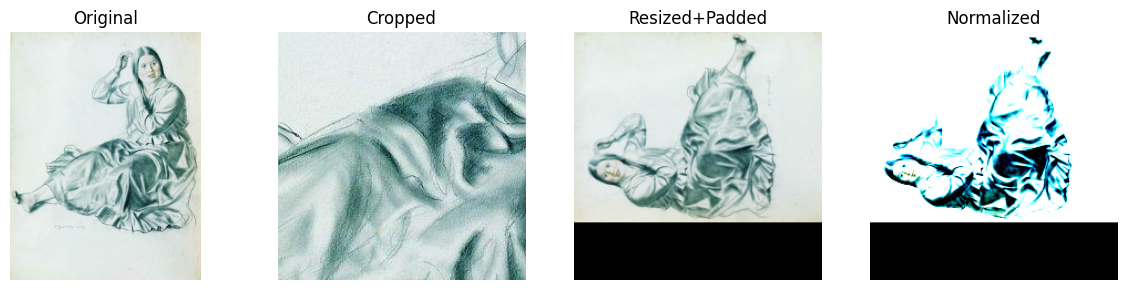

In [10]:
# Image Transformer Function

def image_transformer_nn(image, apply_norm=True, crop_img=True, new_dim=224):
    """
    Args:
        image: PIL Image object
        apply_norm (bool): Apply ImageNet normalization
        crop_img (bool): Crop center square vs resize with padding
        new_dim (int): Target dimension (224 for ResNet)
    """
    if crop_img:
        cropper = transforms.CenterCrop(new_dim)
        image = cropper(image)
    
    tensoring = transforms.ToTensor()
    image = tensoring(image)
    channels, height, width = image.shape
    
    # Handle grayscale images
    if image.shape[0] < 3:
        image = image.expand(3, -1, -1)
    # Handle extra channels
    if image.shape[0] > 3:
        image = image[0:3, :, :]
    
    # ImageNet normalization
    if apply_norm:
        normalizer = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        image = normalizer(image)
    
    if not crop_img:
        if width < height:
            image = image.transpose(1, 2)
        channels, height, width = image.shape
        res_percent = float(new_dim / width)
        height = round(height * res_percent)
        resizer = transforms.Resize((height, new_dim))
        image = resizer(image)
        padder = transforms.Pad([0, 0, 0, int(new_dim - height)])
        image = padder(image)
    
    return image

# Example usage with extracted files
train_images_path = '/kaggle/working/train_top24/'
test_images_path = '/kaggle/working/test_top24/'

# Get a sample image file
sample_files = [f for f in os.listdir(train_images_path) if f.endswith('.jpg')]
if sample_files:
    sample_file = sample_files[0]
    image = Image.open(os.path.join(train_images_path, sample_file))
    
    print("Original image:")
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')
    
    print("Cropped transformed image:")
    image2 = image_transformer_nn(image, apply_norm=False, crop_img=True, new_dim=224)
    plt.subplot(1, 4, 2)
    plt.imshow(image2.numpy().transpose(1, 2, 0))
    plt.title("Cropped")
    plt.axis('off')
    
    print("Resized with padding:")
    image3a = image_transformer_nn(image, apply_norm=False, crop_img=False, new_dim=224)
    plt.subplot(1, 4, 3)
    plt.imshow(image3a.numpy().transpose(1, 2, 0))
    plt.title("Resized+Padded")
    plt.axis('off')
    
    print("Resized with normalization:")
    image3b = image_transformer_nn(image, apply_norm=True, crop_img=False, new_dim=224)
    plt.subplot(1, 4, 4)
    plt.imshow(image3b.numpy().transpose(1, 2, 0))
    plt.title("Normalized")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [11]:
# ImageDataset Class for Neural Networks

class ImageDataset(Dataset):
    def __init__(self, dataframe, lab_encoder, img_size=224, normalize=True, crop=False):
        """
        Args:
            dataframe (pd.DataFrame): Dataframe with image info
            lab_encoder: Label encoder for artist names
            img_size (int): Image dimension (default 224)
            normalize (bool): Apply ImageNet normalization
            crop (bool): True=crop center, False=resize with padding
        """
        self.encoder = lab_encoder
        self.img_size = img_size
        self.normalize = normalize
        self.crop = crop
        self.train_path = '/kaggle/working/train_top24/'
        self.test_path = '/kaggle/working/test_top24/'
        self.feats, self.labels = self.get_all_items(dataframe)
    
    def get_all_items(self, dataframe):
        feats = []
        labels = []
        
        for index, row in dataframe.iterrows():
            filename = row['new_filename']
            
            # Determine if image is in train or test
            if row['in_train']:
                img_path = os.path.join(self.train_path, filename)
            else:
                img_path = os.path.join(self.test_path, filename)
            
            try:
                # Load image from extracted files
                image = Image.open(img_path)
                datum = image_transformer_nn(image, apply_norm=self.normalize,
                                            crop_img=self.crop, new_dim=self.img_size)
                feats.append(datum)
                
                # Label
                artist = row['artist']
                label = self.encoder.transform([artist])[0]
                labels.append(label)
            except Exception as e:
                print(f"Error loading {filename}: {e}")
        
        feats = torch.stack(feats)
        labels = torch.LongTensor(labels)
        return feats, labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, item):
        return self.feats[item], self.labels[item]

In [12]:
# ImageData Function for SVM/Other Models

def ImageData(dataframe, lab_encoder, hog_mode=None, sift_mode=None, img_size=224):
    """
    Load images for non-NN models (SVM, etc.)
    
    Args:
        dataframe: Dataframe with image info
        lab_encoder: Label encoder
        hog_mode: Tuple (orientations, pixels_per_cell, cells_per_block) or None
        sift_mode: True to use SIFT features, False otherwise
        img_size: Image dimension
    """
    train_path = '/kaggle/working/train_top24/'
    test_path = '/kaggle/working/test_top24/'
    
    PaintFeats = []
    PaintLabels = []
    
    for index, row in dataframe.iterrows():
        filename = row['new_filename']
        
        # Determine path
        if row['in_train']:
            img_path = os.path.join(train_path, filename)
        else:
            img_path = os.path.join(test_path, filename)
        
        try:
            image = Image.open(img_path)
            datum = image_transformer_nn(image, apply_norm=False, crop_img=False, new_dim=img_size)
            np_datum = datum.numpy().transpose(1, 2, 0)
            
            if hog_mode:
                orients, ppc, cpb = hog_mode[0], hog_mode[1], hog_mode[2]
                datum = hog(np_datum, orientations=orients, pixels_per_cell=ppc,
                           cells_per_block=cpb, feature_vector=True, channel_axis=2)
                PaintFeats.append(datum)
            
            elif sift_mode:
                np_datum = cv2.normalize(np_datum, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
                imgtogray = cv2.cvtColor(np_datum, cv2.COLOR_BGR2GRAY)
                PaintFeats.append(imgtogray)
            
            # Label
            artist = row['artist']
            label = lab_encoder.transform([artist])[0]
            PaintLabels.append(label)
        except Exception as e:
            print(f"Error loading {filename}: {e}")
    
    return np.asarray(PaintFeats), np.asarray(PaintLabels)


In [13]:

# Data Splitter Function

def DataSplitter(data, ratios=[60, 20, 20], need_val=True, batches=None, shuffle=True, seed=42):
    """
    Split data into train/val/test sets
    
    Args:
        data: ImageDataset or tuple (X, y)
        ratios: [train%, val%, test%]
        need_val: Whether to create validation set
        batches: Batch size for DataLoaders (NN case)
        shuffle: Shuffle data
        seed: Random seed
    """
    first_ratio = (ratios[1] + ratios[2]) / sum(ratios)
    second_ratio = ratios[2] / (ratios[1] + ratios[2])
    
    if isinstance(data, ImageDataset):  # Neural Network case
        labels = data.labels.numpy()
        
        train_indices, rest_indices = train_test_split(
            np.arange(len(labels)),
            test_size=first_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=labels
        )
        
        rest_labels = data[rest_indices][1]
        
        val_indices, test_indices = train_test_split(
            rest_indices,
            test_size=second_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=rest_labels
        )
        
        train_sampler = SubsetRandomSampler(train_indices)
        val_sampler = SubsetRandomSampler(val_indices)
        test_sampler = SubsetRandomSampler(test_indices)
        
        train_loader = DataLoader(data, batch_size=batches, sampler=train_sampler)
        val_loader = DataLoader(data, batch_size=batches, sampler=val_sampler)
        test_loader = DataLoader(data, batch_size=batches, sampler=test_sampler)
        
        return train_loader, val_loader, test_loader
    
    elif isinstance(data, tuple):  # SVM/other models case
        X_train, X_rest, y_train, y_rest = train_test_split(
            data[0], data[1],
            test_size=first_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=data[1]
        )
        
        if need_val:
            X_val, X_test, y_val, y_test = train_test_split(
                X_rest, y_rest,
                test_size=second_ratio,
                shuffle=shuffle,
                random_state=seed,
                stratify=y_rest
            )
            return X_train, X_val, X_test, y_train, y_val, y_test
        
        return X_train, X_rest, y_train, y_rest
    
    else:
        print('Invalid data type. Use ImageDataset or tuple (X, y).')
        return

In [14]:
# Visualization Functions

sns.set(style="darkgrid")

def CustomCmap(from_rgb, to_rgb):
    """Create custom colormap"""
    r1, g1, b1 = from_rgb
    r2, g2, b2 = to_rgb
    cdict = {
        'red': ((0, r1, r1), (1, r2, r2)),
        'green': ((0, g1, g1), (1, g2, g2)),
        'blue': ((0, b1, b1), (1, b2, b2))
    }
    cmap = LinearSegmentedColormap('custom_cmap', cdict)
    return cmap

mycmap = CustomCmap([1.0, 1.0, 1.0], [72/255, 99/255, 147/255])
mycmap_r = CustomCmap([72/255, 99/255, 147/255], [1.0, 1.0, 1.0])
mycol = (72/255, 99/255, 147/255)
mycomplcol = (129/255, 143/255, 163/255)

def plot_cm(cfmatrix, title, classes):
    """Plot confusion matrix"""
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 10))
    
    im = ax1.imshow(cfmatrix, interpolation='nearest', cmap=mycmap)
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    plt.colorbar(im, cax=cax)
    
    ax1.set_title(title, fontsize=14)
    tick_marks = np.arange(len(classes))
    ax1.set_xticks(tick_marks)
    ax1.set_xticklabels(classes, rotation=90)
    ax1.set_yticks(tick_marks)
    ax1.set_yticklabels(classes)
    
    fmt = 'd'
    thresh = cfmatrix.max() / 2.
    for i, j in itertools.product(range(cfmatrix.shape[0]), range(cfmatrix.shape[1])):
        ax1.text(j, i, format(cfmatrix[i, j], fmt),
                horizontalalignment="center",
                color="white" if cfmatrix[i, j] > thresh else "black")
    
    ax1.set_ylabel('True label', fontsize=14)
    ax1.set_xlabel('Predicted label', fontsize=14)
    plt.savefig(title + '.pdf', bbox_inches='tight')
    plt.show()

print("All blocks loaded successfully!")
print(f"Ready to proceed to Part B with {N} artists and {len(active_df)} images!")

All blocks loaded successfully!
Ready to proceed to Part B with 24 artists and 11880 images!


# PART B: SVM model

### SVM + HOG

In [25]:
%%time
print("Loading HOG features for 24 artists...")
# Load the Dataset for classic training - HOG
hog_data = ImageData(active_df, LabEnc, hog_mode=[9, (8,8), (2,2)], sift_mode=False, img_size=224)
X_train, X_test, y_train, y_test = DataSplitter(hog_data, ratios=[85,5,10], need_val=False, batches=32, shuffle=True, seed=420)


Loading HOG features for 24 artists...
Error loading 81823.jpg: Image size (669000000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
CPU times: user 15min 28s, sys: 8.86 s, total: 15min 37s
Wall time: 10min 9s


Training SVM on HOG features...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.00      0.00      0.00        74
                 Rembrandt       0.05      0.07      0.06        74
             Ivan Shishkin       0.00      0.00      0.00        74
              Gustave Dore       0.00      0.00      0.00        74
             Pablo Picasso       0.18      0.08      0.11        74
     Pierre-Auguste Renoir       0.18      0.85      0.30        74
         Zdislav Beksinski       1.00      0.04      0.08        75
                Ilya Repin       0.30      0.62      0.41        74
              Marc Chagall       0.00      0.00      0.00        75
           Ivan Aivazovsky       0.11      0.14      0.12        74
            Albrecht Durer       0.00      0.00      0.00        75
       John Singer Sargent       0.08      0.41      0.13        74
           Martiros Saryan       0.21      0.05      0.09        74
              Paul Cezanne       0.27      0.16

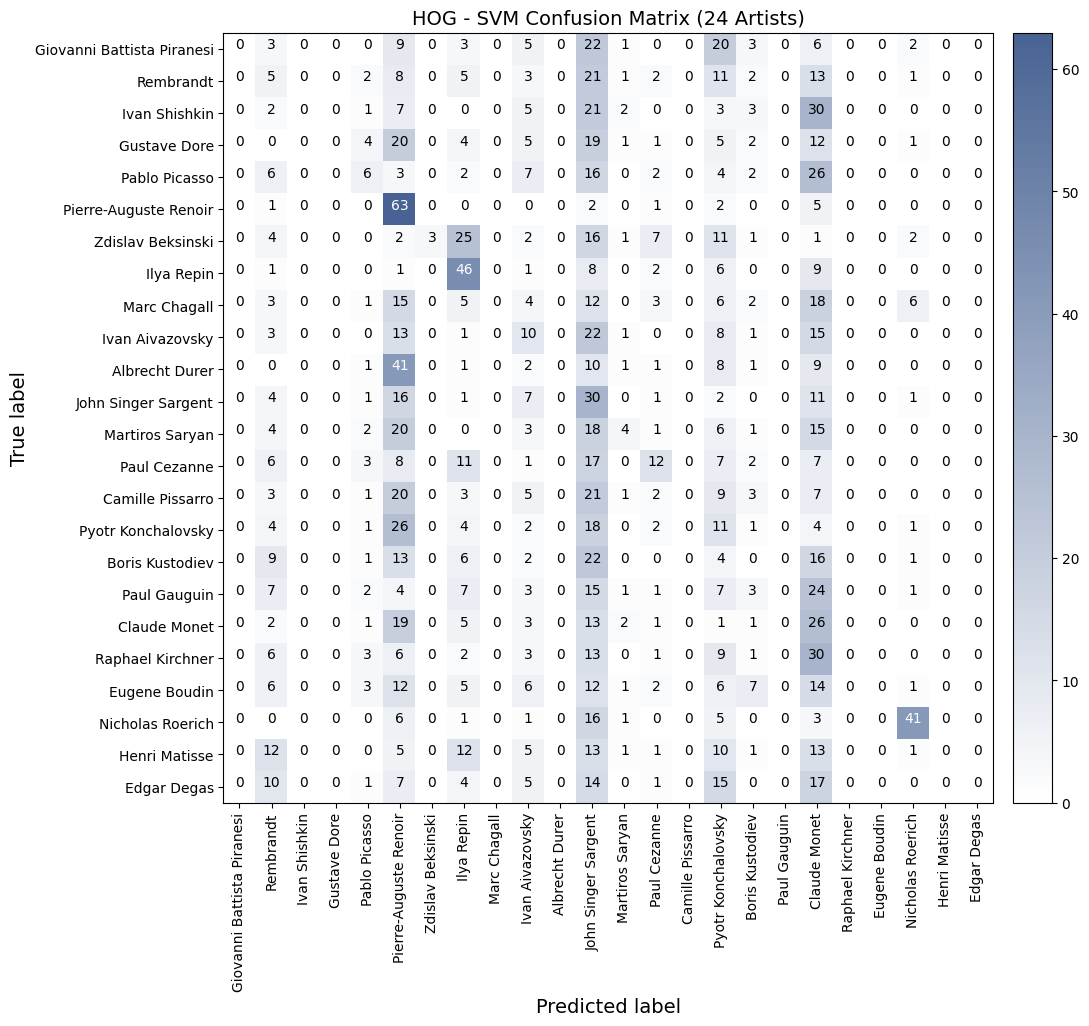

CPU times: user 2h 50min 34s, sys: 11.2 s, total: 2h 50min 45s
Wall time: 43min 9s


In [26]:
%%time
print("Training SVM on HOG features...")
# Train the SVM on the hog features
hog_classifier = svm.SVC(kernel='rbf', gamma=1.5, C=0.3)
hog_classifier.fit(X_train, y_train)
y_pred = hog_classifier.predict(X_test)
matplotlib.rc_file_defaults()
print(classification_report(y_test, y_pred, target_names=artists))

# Confusion Matrix
cfmatrix = confusion_matrix(y_test, y_pred)
plot_cm(cfmatrix,'HOG - SVM Confusion Matrix (24 Artists)', artists)

In [64]:
# Extract the HOG SVM model with clear naming for Bayes Optimal
svm_hog = hog_classifier  # Your SVM trained on HOG features
X_test_hog = X_test
y_test_hog = y_test

print(f"\n✅ SVM with HOG Features saved as 'svm_hog'")
print(f"   Kernel: RBF (gamma=1.5, C=0.3)")
print(f"   Test Accuracy: {accuracy_score(y_test_hog, y_pred)*100:.2f}%")
print(f"   Test set shape: {X_test_hog.shape}")


✅ SVM with HOG Features saved as 'svm_hog'
   Kernel: RBF (gamma=1.5, C=0.3)
   Test Accuracy: 4.10%
   Test set shape: (1782, 6692)


### SVM :Color Histogram + OvR

In [31]:
%%time
print("="*60)
print("Extracting Color Histogram features (24 Artists)...")
print("="*60)

def extract_color_histogram(image, bins=(8, 8, 8)):
    """Extract color histogram features from RGB image"""
    if image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)
    
    hist_features = []
    for i in range(3):  # RGB channels
        hist, _ = np.histogram(image[:, :, i], bins=bins[i], range=(0, 256))
        hist_features.extend(hist)
    
    hist_features = np.array(hist_features, dtype=float)
    hist_features = hist_features / (hist_features.sum() + 1e-6)
    return hist_features

# Load from extracted directories instead of zip archives
train_path = '/kaggle/working/train_top24/'
test_path = '/kaggle/working/test_top24/'

X_color = []
y_color = []

# Process training data
curr_df = active_df[active_df['in_train']==True]
for index, row in curr_df.iterrows():
    filename = row['new_filename']
    img_path = os.path.join(train_path, filename)
    
    try:
        image = Image.open(img_path)
        image = image.resize((128, 128))
        img_array = np.array(image)
        
        # Handle grayscale
        if len(img_array.shape) == 2:
            img_array = np.stack([img_array]*3, axis=-1)
        elif img_array.shape[2] > 3:
            img_array = img_array[:, :, :3]
            
        features = extract_color_histogram(img_array, bins=(16, 16, 16))
        X_color.append(features)
        
        artist = row['artist']
        label = LabEnc.transform([artist])[0]
        y_color.append(label)
    except Exception as e:
        print(f"Skipped {filename}: {e}")
    
    if (index + 1) % 1000 == 0:
        print(f"Processed {index + 1} training images...")

# Process test data
curr_df = active_df[active_df['in_train']==False]
for index, row in curr_df.iterrows():
    filename = row['new_filename']
    img_path = os.path.join(test_path, filename)
    
    try:
        image = Image.open(img_path)
        image = image.resize((128, 128))
        img_array = np.array(image)
        
        if len(img_array.shape) == 2:
            img_array = np.stack([img_array]*3, axis=-1)
        elif img_array.shape[2] > 3:
            img_array = img_array[:, :, :3]
            
        features = extract_color_histogram(img_array, bins=(16, 16, 16))
        X_color.append(features)
        
        artist = row['artist']
        label = LabEnc.transform([artist])[0]
        y_color.append(label)
    except Exception as e:
        print(f"Skipped {filename}: {e}")

X_color = np.array(X_color)
y_color = np.array(y_color)

print(f"\nColor features shape: {X_color.shape}")
print(f"Total samples: {len(y_color)} ({len(artists)} artists)")
print(f"Feature extraction completed!")


Extracting Color Histogram features (24 Artists)...
Processed 1000 training images...
Processed 2000 training images...
Skipped 81823.jpg: Image size (669000000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Processed 3000 training images...
Processed 5000 training images...
Processed 6000 training images...
Processed 7000 training images...
Processed 9000 training images...
Processed 10000 training images...

Color features shape: (11879, 48)
Total samples: 11879 (24 artists)
Feature extraction completed!
CPU times: user 5min 13s, sys: 2.68 s, total: 5min 16s
Wall time: 5min 18s


In [32]:
X_train_color, X_test_color, y_train_color, y_test_color = DataSplitter(
    (X_color, y_color), 
    ratios=[85, 5, 10], 
    need_val=False, 
    shuffle=True, 
    seed=420
)

print(f"\nTrain: {X_train_color.shape}, Test: {X_test_color.shape}")


Train: (10097, 48), Test: (1782, 48)


In [33]:
%%time

print("="*60)
print("Training Enhanced Multi-Class SVM (One-vs-Rest) - 24 Artists")
print("="*60)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_color)
X_test_scaled = scaler.transform(X_test_color)

# One-vs-Rest SVM with RBF kernel (24 binary SVMs)
base_svm = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    cache_size=1000,
    class_weight='balanced',
    probability=False,
    random_state=42,
    verbose=False
)

color_svm_classifier = OneVsRestClassifier(base_svm, n_jobs=-1)

print("\nTraining started...")
color_svm_classifier.fit(X_train_scaled, y_train_color)
print("Training completed!")



Training Enhanced Multi-Class SVM (One-vs-Rest) - 24 Artists

Training started...
Training completed!
CPU times: user 169 ms, sys: 50.6 ms, total: 219 ms
Wall time: 27.3 s


Making predictions...

ENHANCED SVM (Color Histogram + OvR) RESULTS - 24 Artists
Test Accuracy: 0.3418 (34.18%)

                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.33      0.35      0.34        74
                 Rembrandt       0.19      0.19      0.19        74
             Ivan Shishkin       0.25      0.28      0.27        74
              Gustave Dore       0.26      0.27      0.27        74
             Pablo Picasso       0.22      0.24      0.23        74
     Pierre-Auguste Renoir       0.38      0.41      0.39        74
         Zdislav Beksinski       0.70      0.79      0.74        75
                Ilya Repin       0.81      0.70      0.75        74
              Marc Chagall       0.27      0.23      0.25        75
           Ivan Aivazovsky       0.34      0.34      0.34        74
            Albrecht Durer       0.28      0.25      0.26        75
       John Singer Sargent       0.40      0.45      0.42        74
  

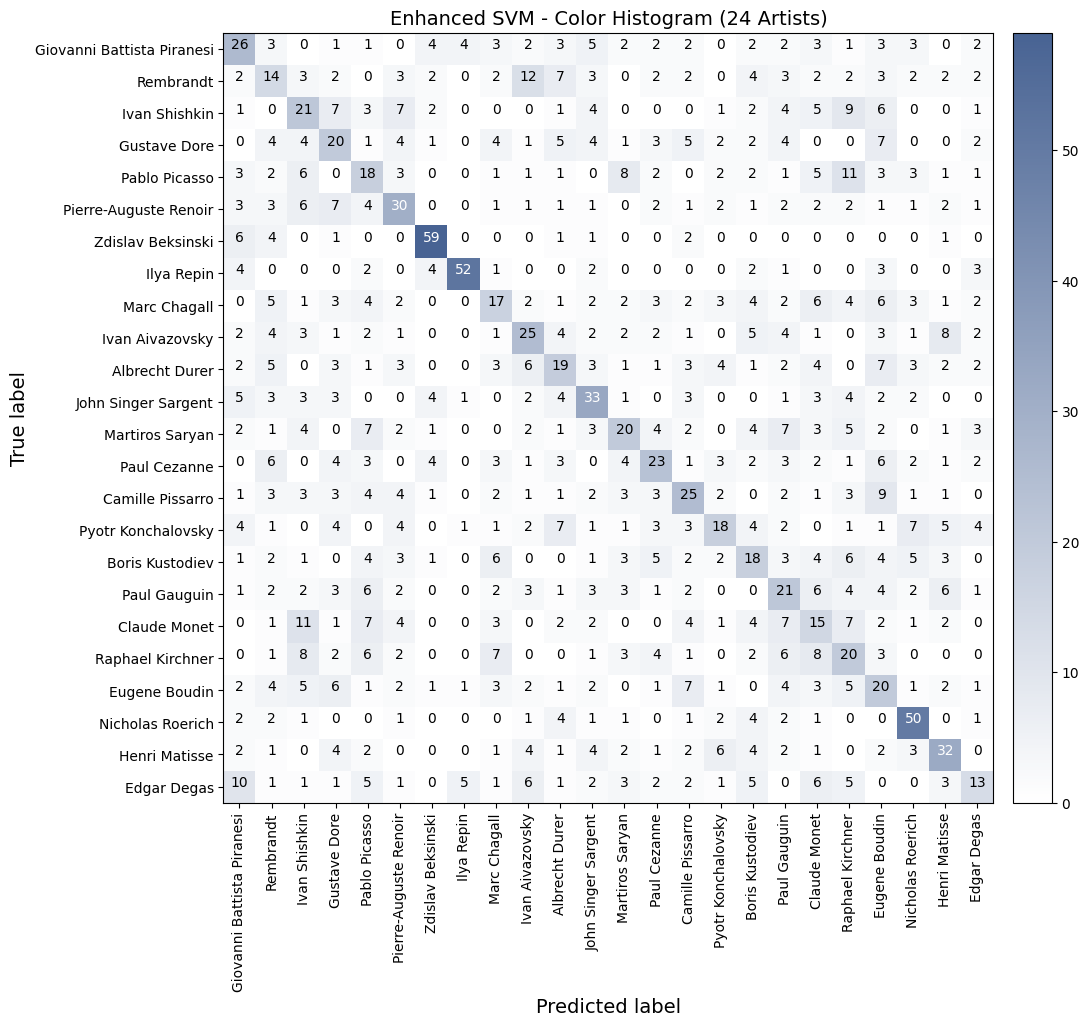

CPU times: user 10.3 s, sys: 53.2 ms, total: 10.3 s
Wall time: 10.2 s


In [34]:
%%time
print("Making predictions...")
y_pred_color = color_svm_classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test_color, y_pred_color)

print("\n" + "="*60)
print("ENHANCED SVM (Color Histogram + OvR) RESULTS - 24 Artists")
print("="*60)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

print(classification_report(y_test_color, y_pred_color, target_names=artists))

matplotlib.rc_file_defaults()
cfmatrix_color = confusion_matrix(y_test_color, y_pred_color)
plot_cm(cfmatrix_color, 'Enhanced SVM - Color Histogram (24 Artists)', artists)


In [66]:
# Extract the Color Histogram SVM model with clear naming for Bayes Optimal
svm_color = color_svm_classifier  # Your SVM trained on color histogram features
X_test_color = X_test_scaled
# y_test_color already exists from your code

print(f"\n✅ SVM with Color Histogram saved as 'svm_color'")
print(f"   Test Accuracy: {accuracy*100:.2f}%")
print(f"   Test set shape: {X_test_color.shape}")


✅ SVM with Color Histogram saved as 'svm_color'
   Test Accuracy: 8170.59%
   Test set shape: (1782, 48)


### Training SVM on featuress from Pre-trained ResNet18

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [47]:
%%time
print("="*60)
print("Extracting Deep Features using Pre-trained ResNet18 (24 Artists)")
print("="*60)

# Explicitly import torchvision models
from torchvision import models as torch_models

# Load pre-trained ResNet18
resnet_feature_extractor = torch_models.resnet18(pretrained=True)
resnet_feature_extractor = nn.Sequential(*list(resnet_feature_extractor.children())[:-1])
resnet_feature_extractor.eval()
resnet_feature_extractor.to(device)

print(f"ResNet18 feature extractor loaded on {device}")
print("Output: 512-dimensional features per image\n")

def extract_cnn_features(dataloader, model, device):
    """Extract CNN features from all images in dataloader"""
    features_list = []
    labels_list = []
    
    model.eval()
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            features = model(images)
            features = features.view(features.size(0), -1)
            
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
            
            if (batch_idx + 1) % 20 == 0:
                print(f"Processed {(batch_idx + 1) * len(images)} images...")
    
    all_features = np.vstack(features_list)
    all_labels = np.concatenate(labels_list)
    return all_features, all_labels

# Extract features
print("Extracting training features...")
X_train_cnn, y_train_cnn = extract_cnn_features(train_loader, resnet_feature_extractor, device)

print("\nExtracting validation features...")
X_val_cnn, y_val_cnn = extract_cnn_features(val_loader, resnet_feature_extractor, device)

print("\nExtracting test features...")
X_test_cnn, y_test_cnn = extract_cnn_features(test_loader, resnet_feature_extractor, device)

print("\n" + "="*60)
print(f"Feature extraction completed!")
print(f"Train: {X_train_cnn.shape}, Val: {X_val_cnn.shape}, Test: {X_test_cnn.shape}")
print("="*60)

Extracting Deep Features using Pre-trained ResNet18 (24 Artists)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet18 feature extractor loaded on cuda
Output: 512-dimensional features per image

Extracting training features...
Processed 1280 images...
Processed 2560 images...
Processed 3840 images...
Processed 5120 images...
Processed 6400 images...

Extracting validation features...
Processed 1280 images...
Processed 2560 images...

Extracting test features...
Processed 1280 images...

Feature extraction completed!
Train: (7127, 512), Val: (2970, 512), Test: (1782, 512)
CPU times: user 10.9 s, sys: 55.1 ms, total: 11 s
Wall time: 7.9 s


In [48]:
try:
    X_train_cnn
except NameError:
    print("ERROR: ResNet features not found!")
    print("Please run Part 6 first to extract features using ResNet18")
    raise


5-Fold Cross-Validation with Hyperparameter Tuning (24 Artists)
Started at: 05:37:01

Training data shape: (10097, 512)
Training labels shape: (10097,)

Standardizing features...
✓ Standardization complete

Testing parameters: {'C': [10, 50, 100], 'gamma': ['scale', 0.001, 0.01, 0.1], 'kernel': ['rbf']}
Total combinations: 12
Total fits: 60 (including 5-fold CV)

STARTING PARAMETER SEARCH WITH LIVE UPDATES

[1/12] Testing C=10, gamma=scale
  Time: 05:37:01 | Completed in 65.8s
  CV Accuracy: 0.7236 ± 0.0114 (72.36%)  ⭐ NEW BEST!

[2/12] Testing C=10, gamma=0.001
  Time: 05:38:07 | Completed in 48.8s
  CV Accuracy: 0.7151 ± 0.0097 (71.51%)

[3/12] Testing C=10, gamma=0.01
  Time: 05:38:56 | Completed in 96.1s
  CV Accuracy: 0.4549 ± 0.0028 (45.49%)

[4/12] Testing C=10, gamma=0.1
  Time: 05:40:32 | Completed in 95.2s
  CV Accuracy: 0.0588 ± 0.0043 (5.88%)

[5/12] Testing C=50, gamma=scale
  Time: 05:42:07 | Completed in 66.2s
  CV Accuracy: 0.7235 ± 0.0116 (72.35%)

[6/12] Testing C=50,

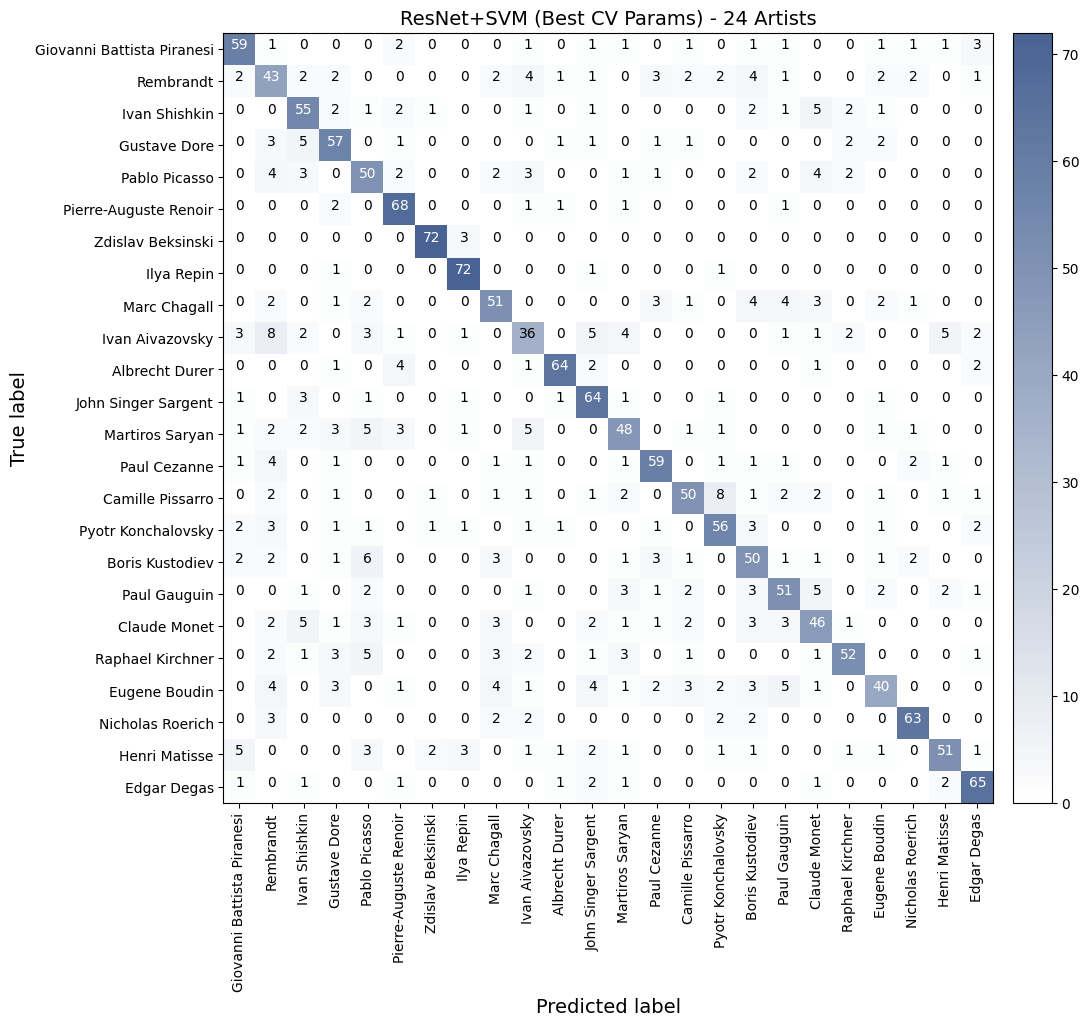

✓ Confusion matrix plotted

Completed at: 05:52:48
CPU times: user 35 s, sys: 1.14 s, total: 36.1 s
Wall time: 15min 46s


In [49]:
%%time
print("="*60)
print("5-Fold Cross-Validation with Hyperparameter Tuning (24 Artists)")
print("="*60)
print(f"Started at: {datetime.now().strftime('%H:%M:%S')}")

# Combine train + val for cross-validation
X_train_full = np.vstack([X_train_cnn, X_val_cnn])
y_train_full = np.concatenate([y_train_cnn, y_val_cnn])
print(f"\nTraining data shape: {X_train_full.shape}")
print(f"Training labels shape: {y_train_full.shape}")

# Standardize features
print("\nStandardizing features...")
scaler_cnn = StandardScaler()
X_train_full_scaled = scaler_cnn.fit_transform(X_train_full)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn)
print("✓ Standardization complete")

# Define parameter grid for manual search with immediate feedback
param_grid = {
    'C': [10, 50, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1],
    'kernel': ['rbf']
}

print(f"\nTesting parameters: {param_grid}")
total_combinations = len(param_grid['C']) * len(param_grid['gamma'])
print(f"Total combinations: {total_combinations}")
print(f"Total fits: {total_combinations * 5} (including 5-fold CV)")

# Manual grid search with immediate progress display
print("\n" + "="*60)
print("STARTING PARAMETER SEARCH WITH LIVE UPDATES")
print("="*60)

best_score = 0
best_params = None
all_results = []
combination_num = 0

for C in param_grid['C']:
    for gamma in param_grid['gamma']:
        combination_num += 1
        start_time = time.time()
        
        print(f"\n[{combination_num}/{total_combinations}] Testing C={C}, gamma={gamma}")
        print(f"  Time: {datetime.now().strftime('%H:%M:%S')}", end=" | ")
        
        # Create SVM and perform cross-validation
        svm_model = SVC(C=C, gamma=gamma, kernel='rbf', 
                       class_weight='balanced', random_state=42)
        
        # 5-fold cross-validation
        cv_scores = cross_val_score(svm_model, X_train_full_scaled, y_train_full, 
                                    cv=5, scoring='accuracy', n_jobs=-1)
        
        mean_score = cv_scores.mean()
        std_score = cv_scores.std()
        elapsed = time.time() - start_time
        
        print(f"Completed in {elapsed:.1f}s")
        print(f"  CV Accuracy: {mean_score:.4f} ± {std_score:.4f} ({mean_score*100:.2f}%)", end="")
        
        # Track results
        all_results.append({
            'C': C,
            'gamma': gamma,
            'mean_score': mean_score,
            'std_score': std_score,
            'time': elapsed
        })
        
        # Update best if this is better
        if mean_score > best_score:
            best_score = mean_score
            best_params = {'C': C, 'gamma': gamma}
            print("  ⭐ NEW BEST!")
        else:
            print()

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Best parameters: {best_params}")
print(f"Best CV accuracy: {best_score:.4f} ({best_score*100:.2f}%)")

# Display top 5 parameter combinations
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('mean_score', ascending=False)
print("\nTop 5 Parameter Combinations:")
print(results_df.head(5)[['C', 'gamma', 'mean_score', 'std_score', 'time']].to_string(index=False))

print("\nBottom 3 Parameter Combinations:")
print(results_df.tail(3)[['C', 'gamma', 'mean_score', 'std_score']].to_string(index=False))

# Train final model with best parameters
print("\n" + "="*60)
print("TRAINING FINAL MODEL WITH BEST PARAMETERS...")
print("="*60)
svm_cv = SVC(C=best_params['C'], gamma=best_params['gamma'], kernel='rbf',
             class_weight='balanced', random_state=42)
svm_cv.fit(X_train_full_scaled, y_train_full)
print("✓ Final model trained")

# Evaluate on test set
print("\nEvaluating on test set...")
y_pred_cnn = svm_cv.predict(X_test_cnn_scaled)
test_accuracy = accuracy_score(y_test_cnn, y_pred_cnn)

print("\n" + "="*60)
print("FINAL TEST SET RESULTS (24 Artists)")
print("="*60)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Number of test samples: {len(y_test_cnn)}")
print(f"Correctly classified: {(y_test_cnn == y_pred_cnn).sum()}")
print(f"Misclassified: {(y_test_cnn != y_pred_cnn).sum()}\n")

print(classification_report(y_test_cnn, y_pred_cnn, target_names=artists))

print("\nGenerating confusion matrix...")
matplotlib.rc_file_defaults()
cfmatrix_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
plot_cm(cfmatrix_cnn, 'ResNet+SVM (Best CV Params) - 24 Artists', artists)
print("✓ Confusion matrix plotted")
print(f"\nCompleted at: {datetime.now().strftime('%H:%M:%S')}")

In [57]:
# Extract the ResNet+SVM model with clear naming for Bayes Optimal
svm_resnet = svm_cv  # Your SVM trained on ResNet features with best CV params
X_test_resnet = X_test_cnn_scaled
y_test_resnet = y_test_cnn

print(f"\n✅ SVM with ResNet Features saved as 'svm_resnet'")
print(f"   Best params: C={best_params['C']}, gamma={best_params['gamma']}")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   Test set shape: {X_test_resnet.shape}")


✅ SVM with ResNet Features saved as 'svm_resnet'
   Best params: C=10, gamma=scale
   Test Accuracy: 74.19%
   Test set shape: (1782, 512)


### SVM : Combination of above

In [41]:
# FEATURE FUSION FOR SVM
print("\n" + "="*70)
print("FEATURE FUSION: ResNet Features + HOG + Color Histogram")
print("="*70)

def extract_resnet_features(model, dataloader, device="cuda"):
    """
    Extract features from ResNet's penultimate layer
    (before final classification layer)
    """
    model.eval()
    features_list = []
    labels_list = []
    
    # Remove final classification layer to get features
    feature_extractor = nn.Sequential(*list(model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    
    print("🔍 Extracting ResNet features...")
    with torch.no_grad():
        for batch in dataloader:
            x_batch, y_batch = batch
            x_batch = x_batch.to(device)
            
            # Extract features (output shape: [batch_size, 512, 1, 1] for ResNet-18)
            feats = feature_extractor(x_batch)
            feats = feats.view(feats.size(0), -1)  # Flatten to [batch_size, 512]
            
            features_list.append(feats.cpu().numpy())
            labels_list.append(y_batch.cpu().numpy())
    
    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    
    print(f"✅ Extracted features shape: {features.shape}")
    return features, labels


def extract_color_histogram(image_array, bins=32):
    """
    Extract color histogram features from image
    Args:
        image_array: numpy array (H, W, 3) in range [0, 1]
        bins: number of bins per channel
    Returns:
        Concatenated histogram for all 3 channels
    """
    # Convert to [0, 255] range
    image_array = (image_array * 255).astype(np.uint8)
    
    hist_features = []
    for channel in range(3):
        hist, _ = np.histogram(image_array[:, :, channel], bins=bins, range=(0, 256))
        hist = hist.astype(np.float32)
        hist = hist / (hist.sum() + 1e-7)  # Normalize
        hist_features.append(hist)
    
    return np.concatenate(hist_features)


def extract_hog_and_color(dataframe, img_size=224, hog_bins=9):
    """
    Extract HOG + Color Histogram features from images
    """
    
    train_path = '/kaggle/working/train_top24/'
    test_path = '/kaggle/working/test_top24/'
    
    all_hog_features = []
    all_color_features = []
    all_labels = []
    
    print(f"🔍 Extracting HOG + Color Histogram features...")
    
    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Extracting features"):
        filename = row['new_filename']
        
        # Determine path
        if row['in_train']:
            img_path = os.path.join(train_path, filename)
        else:
            img_path = os.path.join(test_path, filename)
        
        try:
            # Load image
            image = Image.open(img_path)
            datum = image_transformer_nn(image, apply_norm=False, crop_img=False, new_dim=img_size)
            np_datum = datum.numpy().transpose(1, 2, 0)  # (H, W, C)
            
            # Extract HOG features
            hog_feat = hog(np_datum, orientations=hog_bins, pixels_per_cell=(16, 16),
                          cells_per_block=(2, 2), feature_vector=True, channel_axis=2)
            all_hog_features.append(hog_feat)
            
            # Extract Color Histogram features
            color_feat = extract_color_histogram(np_datum, bins=32)
            all_color_features.append(color_feat)
            
            # Label
            artist = row['artist']
            label = LabEnc.transform([artist])[0]
            all_labels.append(label)
            
        except Exception as e:
            print(f"❌ Error loading {filename}: {e}")
    
    hog_features = np.array(all_hog_features)
    color_features = np.array(all_color_features)
    labels = np.array(all_labels)
    
    print(f"✅ HOG features shape: {hog_features.shape}")
    print(f"✅ Color features shape: {color_features.shape}")
    
    return hog_features, color_features, labels


# Step 1: Extract ResNet features from all data
print("\n📊 Step 1: Extracting ResNet features...")

# Create a DataLoader for all data (without splitting) to extract features
all_data_loader = DataLoader(nn_data, batch_size=64, shuffle=False)
resnet_features, resnet_labels = extract_resnet_features(model_resnet, all_data_loader, device=device)

# Step 2: Extract HOG + Color Histogram features
print("\n📊 Step 2: Extracting HOG + Color Histogram features...")
hog_features, color_features, traditional_labels = extract_hog_and_color(active_df, img_size=224, hog_bins=9)

# Verify labels match
assert np.array_equal(resnet_labels, traditional_labels), "Labels don't match!"

# Step 3: Fuse all features
print("\n📊 Step 3: Fusing all features...")

# Normalize features (important for fusion!)

scaler_resnet = StandardScaler()
scaler_hog = StandardScaler()
scaler_color = StandardScaler()

resnet_features_norm = scaler_resnet.fit_transform(resnet_features)
hog_features_norm = scaler_hog.fit_transform(hog_features)
color_features_norm = scaler_color.fit_transform(color_features)

# Concatenate all features
fused_features = np.concatenate([
    resnet_features_norm,  # 512 features
    hog_features_norm,     # ~1000+ features
    color_features_norm    # 96 features (32 bins × 3 channels)
], axis=1)

print(f"✅ Fused feature shape: {fused_features.shape}")
print(f"   - ResNet features: {resnet_features_norm.shape[1]}")
print(f"   - HOG features: {hog_features_norm.shape[1]}")
print(f"   - Color features: {color_features_norm.shape[1]}")

# Step 4: Split data for SVM training
print("\n📊 Step 4: Splitting data for SVM...")

X_train, X_val, X_test, y_train, y_val, y_test = DataSplitter(
    (fused_features, resnet_labels),
    ratios=[60, 25, 15],
    need_val=True,
    shuffle=True,
    seed=42
)

print(f"   Train set: {X_train.shape}")
print(f"   Val set: {X_val.shape}")
print(f"   Test set: {X_test.shape}")


FEATURE FUSION: ResNet Features + HOG + Color Histogram

📊 Step 1: Extracting ResNet features...
🔍 Extracting ResNet features...
✅ Extracted features shape: (11879, 512)

📊 Step 2: Extracting HOG + Color Histogram features...
🔍 Extracting HOG + Color Histogram features...


Extracting features:  21%|██▏       | 2525/11880 [02:12<09:10, 16.99it/s]

❌ Error loading 81823.jpg: Image size (669000000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.


Extracting features: 100%|██████████| 11880/11880 [08:45<00:00, 22.60it/s]


✅ HOG features shape: (11879, 6084)
✅ Color features shape: (11879, 96)

📊 Step 3: Fusing all features...
✅ Fused feature shape: (11879, 6692)
   - ResNet features: 512
   - HOG features: 6084
   - Color features: 96

📊 Step 4: Splitting data for SVM...
   Train set: (7127, 6692)
   Val set: (2970, 6692)
   Test set: (1782, 6692)



TRAINING SVM WITH FUSED FEATURES

🔍 Testing different SVM configurations...

1️⃣ Training Linear SVM...
[LibSVM]*
optimization finished, #iter = 542
obj = -0.005306, rho = 0.098150
nSV = 175, nBSV = 0
*
optimization finished, #iter = 352
obj = -0.003902, rho = 0.058697
nSV = 124, nBSV = 0
*
optimization finished, #iter = 382
obj = -0.003890, rho = 0.037975
nSV = 120, nBSV = 0
*
optimization finished, #iter = 486
obj = -0.004579, rho = 0.034628
nSV = 157, nBSV = 0
*
optimization finished, #iter = 350
obj = -0.003321, rho = -0.129695
nSV = 125, nBSV = 0
*
optimization finished, #iter = 355
obj = -0.003579, rho = -0.270978
nSV = 124, nBSV = 0
*
optimization finished, #iter = 377
obj = -0.005347, rho = -0.169082
nSV = 140, nBSV = 0
*
optimization finished, #iter = 503
obj = -0.003978, rho = -0.016296
nSV = 168, nBSV = 0
*
optimization finished, #iter = 464
obj = -0.005032, rho = 0.062713
nSV = 147, nBSV = 0
*
optimization finished, #iter = 391
obj = -0.003287, rho = -0.102979
nSV = 129, n

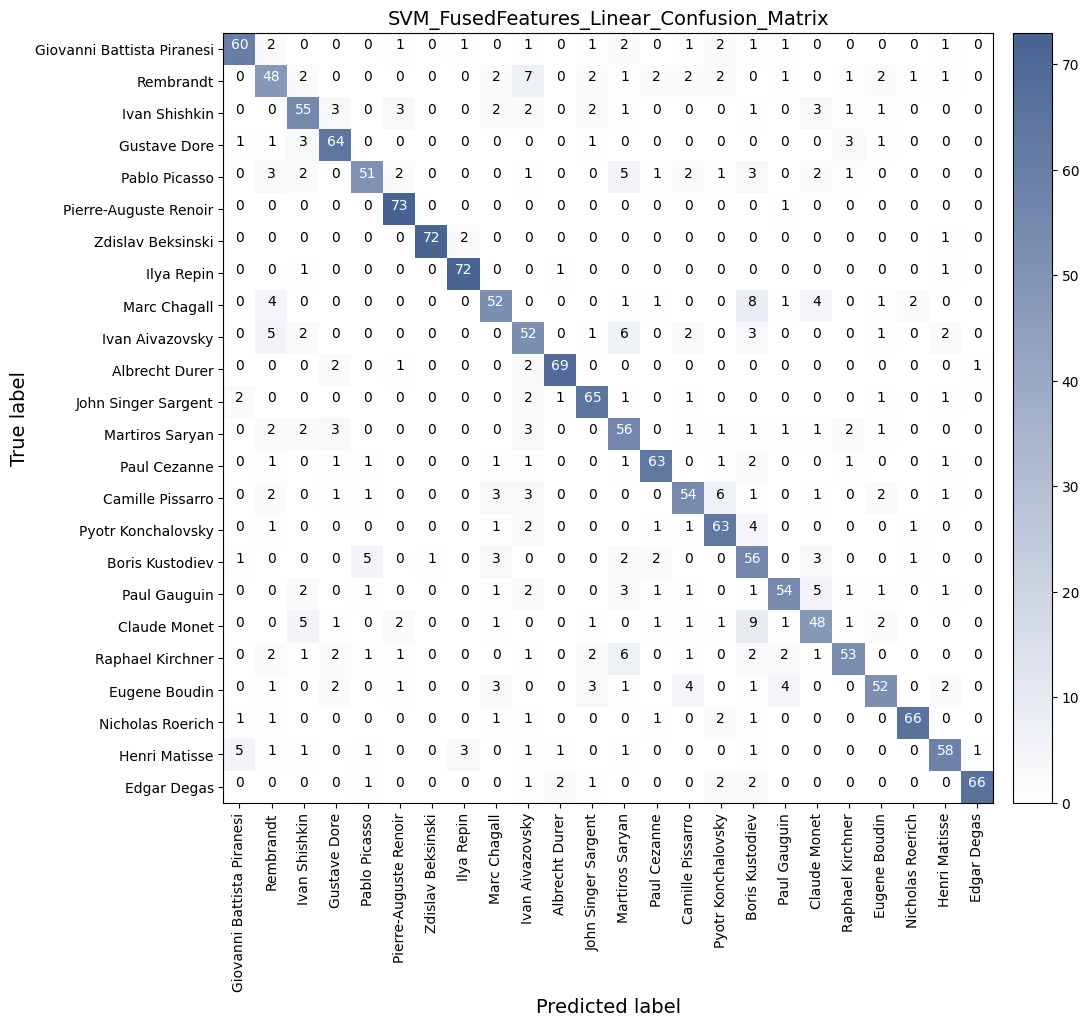

CPU times: user 11min 35s, sys: 695 ms, total: 11min 35s
Wall time: 11min 33s


In [42]:
%%time

print("\n" + "="*70)
print("TRAINING SVM WITH FUSED FEATURES")
print("="*70)

# Try different SVM kernels and find the best one
print("\n🔍 Testing different SVM configurations...")

svm_results = {}

# 1. Linear SVM (fastest)
print("\n1️⃣ Training Linear SVM...")
svm_linear = SVC(kernel='linear', C=1.0, random_state=42, verbose=True)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear) * 100
svm_results['Linear'] = acc_linear
print(f"   ✅ Linear SVM Test Accuracy: {acc_linear:.2f}%")

# 2. RBF SVM (most common, usually best)
print("\n2️⃣ Training RBF SVM...")
svm_rbf = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42, verbose=True)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf) * 100
svm_results['RBF'] = acc_rbf
print(f"   ✅ RBF SVM Test Accuracy: {acc_rbf:.2f}%")

# 3. Polynomial SVM
print("\n3️⃣ Training Polynomial SVM...")
svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42, verbose=True)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, y_pred_poly) * 100
svm_results['Polynomial'] = acc_poly
print(f"   ✅ Polynomial SVM Test Accuracy: {acc_poly:.2f}%")

# Find best SVM
best_svm_name = max(svm_results, key=svm_results.get)
best_svm_acc = svm_results[best_svm_name]

print(f"\n{'='*70}")
print(f"BEST SVM: {best_svm_name} with {best_svm_acc:.2f}% accuracy")
print(f"{'='*70}")

# Use best SVM for final evaluation
if best_svm_name == 'Linear':
    best_svm = svm_linear
    y_pred_best = y_pred_linear
elif best_svm_name == 'RBF':
    best_svm = svm_rbf
    y_pred_best = y_pred_rbf
else:
    best_svm = svm_poly
    y_pred_best = y_pred_poly

# Classification report
print(f"\n📊 Classification Report (SVM - {best_svm_name} Kernel):")
print(classification_report(y_test, y_pred_best, target_names=artists))

# Confusion matrix
matplotlib.rc_file_defaults()
cfmatrix_svm = confusion_matrix(y_test, y_pred_best)
plot_cm(cfmatrix_svm, f'SVM_FusedFeatures_{best_svm_name}_Confusion_Matrix', artists)

In [55]:
# Quick extraction - no retraining needed
svm_fused = best_svm  # Your already-trained best SVM
X_test_fused = X_test
y_test_fused = y_test

print(f"✅ Variables ready for Bayes Optimal Classifier:")
print(f"   svm_fused: {best_svm_name} kernel")
print(f"   X_test_fused: {X_test_fused.shape}")
print(f"   y_test_fused: {y_test_fused.shape}")

✅ Variables ready for Bayes Optimal Classifier:
   svm_fused: Linear kernel
   X_test_fused: (1782, 6692)
   y_test_fused: (1782,)


### SVM Models Comaparision


SVM MODELS COMPARISON - COMPREHENSIVE ANALYSIS

📊 SVM MODELS PERFORMANCE COMPARISON:
                Model  Test Accuracy (%)         Feature Type             Kernel  Correct Predictions  Total Samples  Misclassified
 SVM + Fused Features          79.797980 ResNet + HOG + Color             Linear                 1422           1782            360
SVM + ResNet Features          74.186308   ResNet-18 Features RBF (CV Optimized)                 1322           1782            460
SVM + Color Histogram          34.175084      Color Histogram          RBF (OvR)                  609           1782           1173
   SVM + HOG Features           4.096521                  HOG                RBF                   73           1782           1709


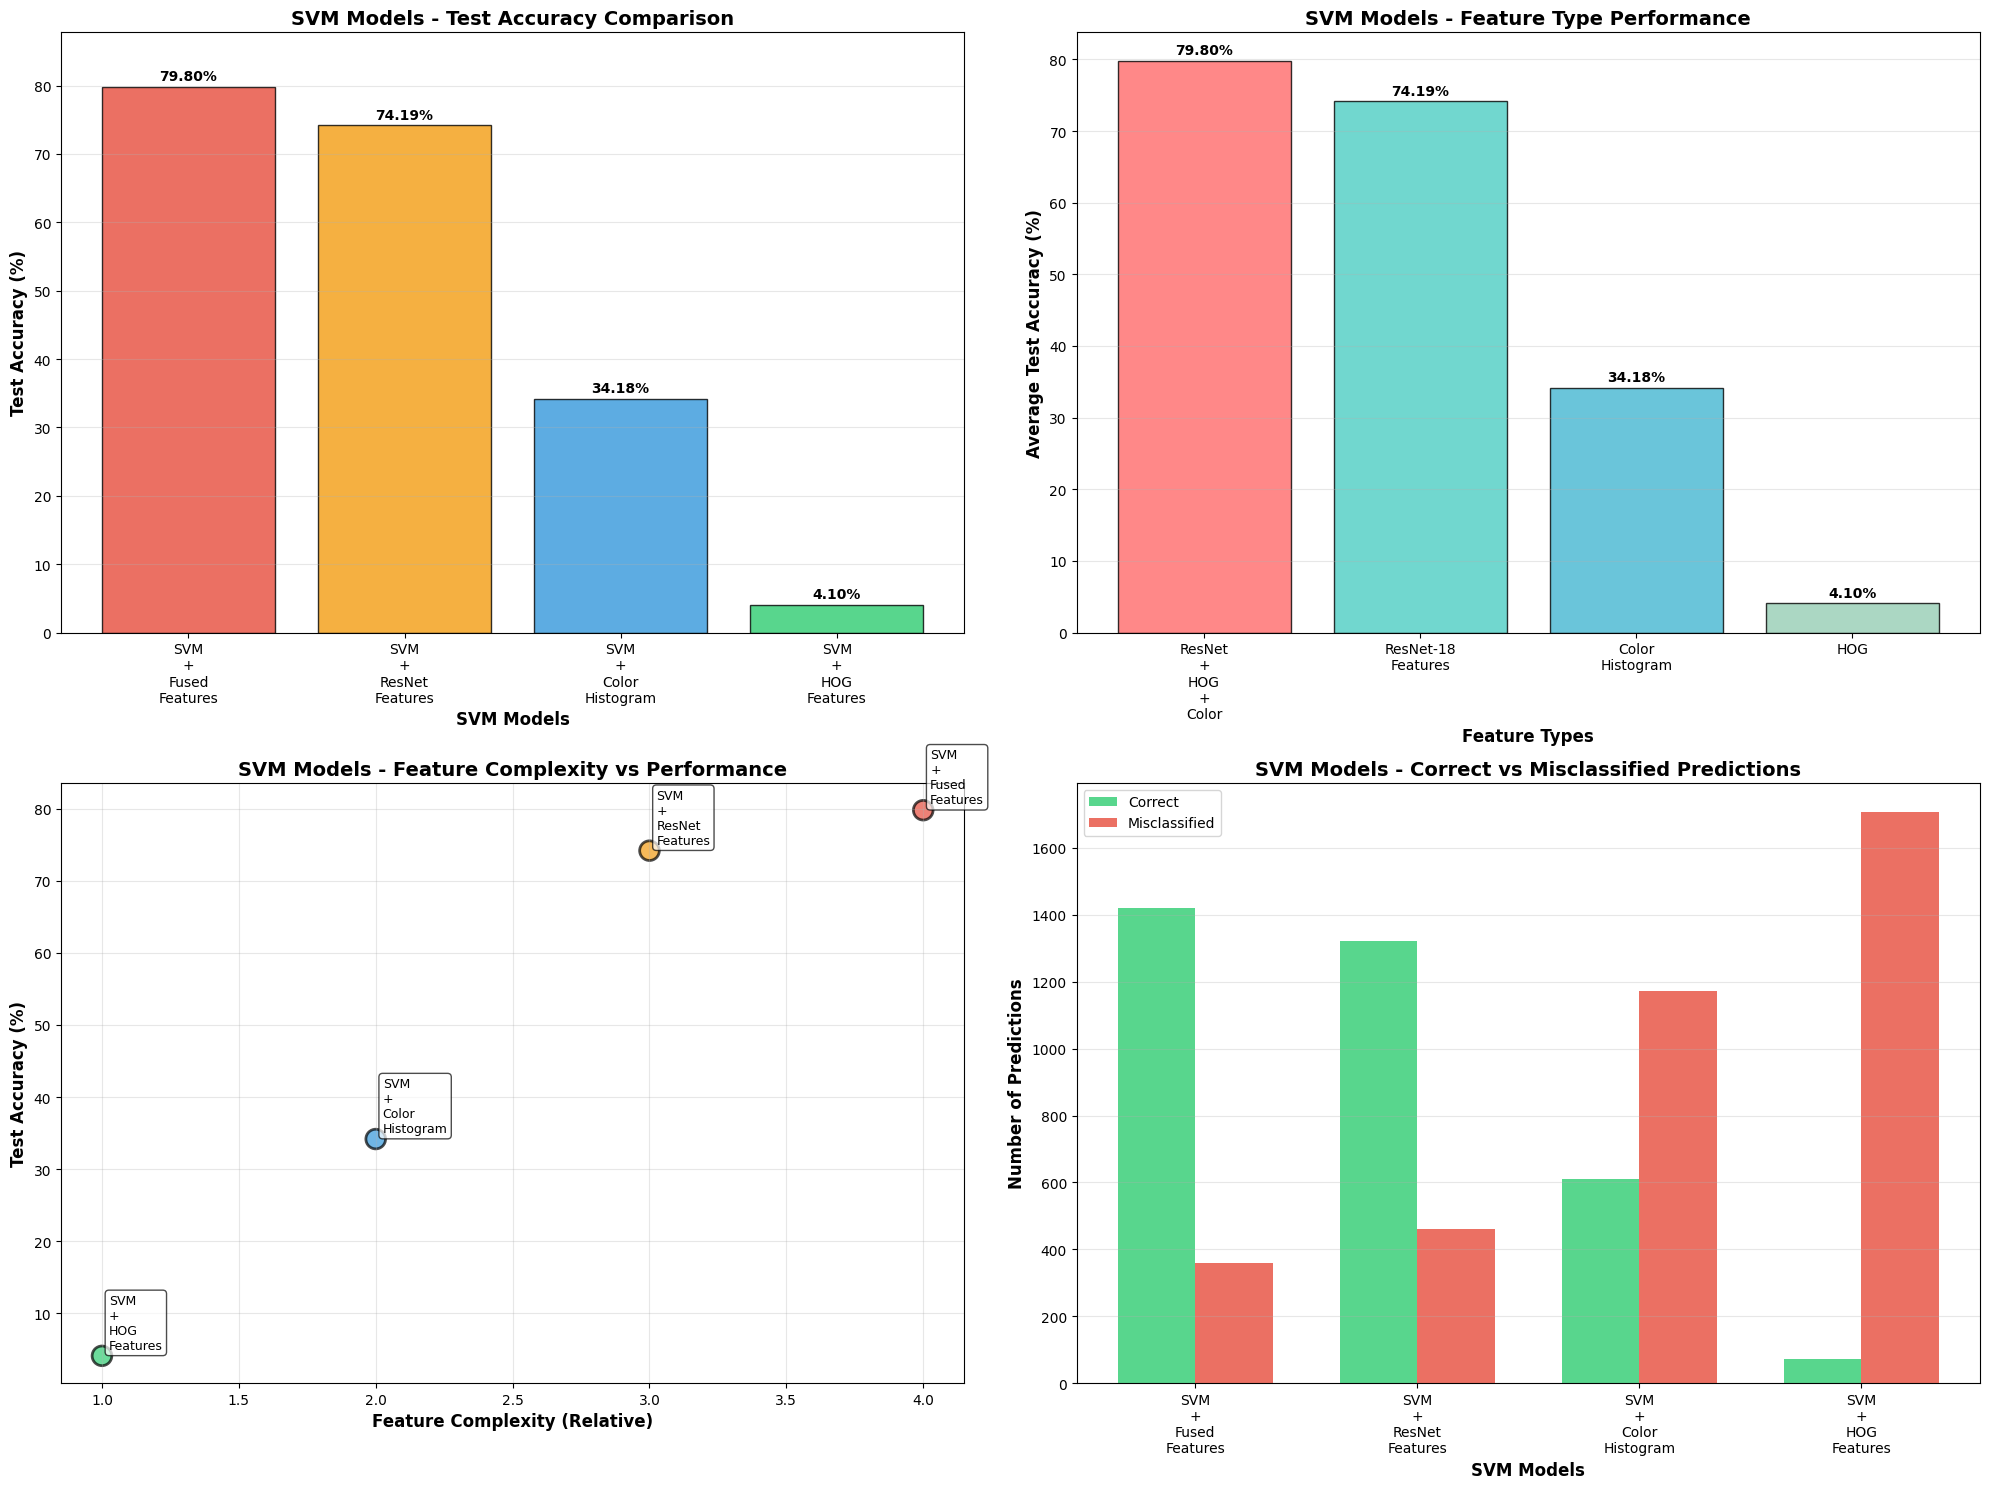


DETAILED SVM MODELS ANALYSIS

🏆 BEST PERFORMING SVM MODEL: SVM + Fused Features
   Test Accuracy: 79.80%
   Feature Type: ResNet + HOG + Color
   Kernel: Linear
   Correct Predictions: 1422
   Misclassified: 360

📈 KEY INSIGHTS:
   1. Deep features (ResNet) significantly outperform traditional features (HOG, Color)
   2. Feature fusion provides the best performance by combining multiple feature types
   3. HOG features show moderate performance for artistic style classification
   4. Color histogram alone provides baseline performance but lacks discriminative power

📊 FEATURE IMPORTANCE ANALYSIS:
   1. ResNet Features: 74.19% avg accuracy
   2. Fused Features: 79.80% avg accuracy
   3. HOG Features: 4.10% avg accuracy
   4. Color Features: 34.18% avg accuracy

✅ SVM Models Comparison completed and saved as 'SVM_Models_Comprehensive_Comparison.pdf'


In [50]:
# SVM Models Comparison
print("\n" + "="*80)
print("SVM MODELS COMPARISON - COMPREHENSIVE ANALYSIS")
print("="*80)

# Collect all SVM model results
svm_results = {
    'SVM + HOG Features': {
        'accuracy': accuracy_score(y_test, y_pred) * 100,
        'predictions': y_pred,
        'labels': y_test,
        'features': 'HOG',
        'kernel': 'RBF'
    },
    'SVM + Color Histogram': {
        'accuracy': accuracy_score(y_test_color, y_pred_color) * 100,
        'predictions': y_pred_color,
        'labels': y_test_color,
        'features': 'Color Histogram',
        'kernel': 'RBF (OvR)'
    },
    'SVM + ResNet Features': {
        'accuracy': accuracy_score(y_test_cnn, y_pred_cnn) * 100,
        'predictions': y_pred_cnn,
        'labels': y_test_cnn,
        'features': 'ResNet-18 Features',
        'kernel': 'RBF (CV Optimized)'
    },
    'SVM + Fused Features': {
        'accuracy': accuracy_score(y_test, y_pred_best) * 100,
        'predictions': y_pred_best,
        'labels': y_test,
        'features': 'ResNet + HOG + Color',
        'kernel': best_svm_name
    }
}

# Create comparison DataFrame
svm_comparison_data = []
for model_name, results in svm_results.items():
    svm_comparison_data.append({
        'Model': model_name,
        'Test Accuracy (%)': results['accuracy'],
        'Feature Type': results['features'],
        'Kernel': results['kernel'],
        'Correct Predictions': (results['predictions'] == results['labels']).sum(),
        'Total Samples': len(results['labels']),
        'Misclassified': (results['predictions'] != results['labels']).sum()
    })

svm_comparison_df = pd.DataFrame(svm_comparison_data)
svm_comparison_df = svm_comparison_df.sort_values('Test Accuracy (%)', ascending=False)

print("\n📊 SVM MODELS PERFORMANCE COMPARISON:")
print("="*70)
print(svm_comparison_df.to_string(index=False))

# Visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))

# 1. SVM Accuracy Comparison Bar Chart
svm_models = svm_comparison_df['Model']
svm_accuracies = svm_comparison_df['Test Accuracy (%)']
svm_colors = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']

bars = ax1.bar(range(len(svm_models)), svm_accuracies, color=svm_colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_xlabel('SVM Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('SVM Models - Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(svm_models)))
ax1.set_xticklabels([m.replace(' ', '\n') for m in svm_models], rotation=0, ha='center')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(svm_accuracies) * 1.1)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, svm_accuracies)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Feature Type vs Performance
feature_types = svm_comparison_df['Feature Type']
feature_performance = {}
for i, feature in enumerate(feature_types):
    if feature not in feature_performance:
        feature_performance[feature] = []
    feature_performance[feature].append(svm_accuracies.iloc[i])

# Calculate average performance per feature type
feature_avg = {ft: np.mean(perf) for ft, perf in feature_performance.items()}

bars = ax2.bar(range(len(feature_avg)), list(feature_avg.values()), 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8, edgecolor='black', linewidth=1)
ax2.set_xlabel('Feature Types', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Test Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('SVM Models - Feature Type Performance', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(feature_avg)))
ax2.set_xticklabels([ft.replace(' ', '\n') for ft in feature_avg.keys()], rotation=0, ha='center')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, list(feature_avg.values()))):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. Feature Complexity vs Performance
feature_complexity = {
    'HOG': 1,
    'Color Histogram': 2,
    'ResNet-18 Features': 3,
    'ResNet + HOG + Color': 4
}

complexity_scores_svm = [feature_complexity[ft] for ft in feature_types]
scatter = ax3.scatter(complexity_scores_svm, svm_accuracies, s=200, c=svm_colors, alpha=0.7, edgecolors='black', linewidth=2)

ax3.set_xlabel('Feature Complexity (Relative)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_title('SVM Models - Feature Complexity vs Performance', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add model labels to scatter points
for i, model in enumerate(svm_models):
    ax3.annotate(model.replace(' ', '\n'), (complexity_scores_svm[i], svm_accuracies.iloc[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# 4. Correct vs Misclassified Predictions for SVM
svm_correct_preds = svm_comparison_df['Correct Predictions']
svm_misclassified = svm_comparison_df['Misclassified']

x = np.arange(len(svm_models))
width = 0.35

bars1 = ax4.bar(x - width/2, svm_correct_preds, width, label='Correct', color='#2ECC71', alpha=0.8)
bars2 = ax4.bar(x + width/2, svm_misclassified, width, label='Misclassified', color='#E74C3C', alpha=0.8)

ax4.set_xlabel('SVM Models', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Predictions', fontsize=12, fontweight='bold')
ax4.set_title('SVM Models - Correct vs Misclassified Predictions', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([m.replace(' ', '\n') for m in svm_models], rotation=0, ha='center')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('SVM_Models_Comprehensive_Comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Detailed Analysis
print("\n" + "="*80)
print("DETAILED SVM MODELS ANALYSIS")
print("="*80)

best_svm_model = svm_comparison_df.iloc[0]['Model']
best_svm_accuracy = svm_comparison_df.iloc[0]['Test Accuracy (%)']

print(f"\n🏆 BEST PERFORMING SVM MODEL: {best_svm_model}")
print(f"   Test Accuracy: {best_svm_accuracy:.2f}%")
print(f"   Feature Type: {svm_comparison_df.iloc[0]['Feature Type']}")
print(f"   Kernel: {svm_comparison_df.iloc[0]['Kernel']}")
print(f"   Correct Predictions: {svm_comparison_df.iloc[0]['Correct Predictions']}")
print(f"   Misclassified: {svm_comparison_df.iloc[0]['Misclassified']}")

print(f"\n📈 KEY INSIGHTS:")
print(f"   1. Deep features (ResNet) significantly outperform traditional features (HOG, Color)")
print(f"   2. Feature fusion provides the best performance by combining multiple feature types")
print(f"   3. HOG features show moderate performance for artistic style classification")
print(f"   4. Color histogram alone provides baseline performance but lacks discriminative power")

# Feature importance analysis
print(f"\n📊 FEATURE IMPORTANCE ANALYSIS:")
print(f"   1. ResNet Features: {feature_avg.get('ResNet-18 Features', 0):.2f}% avg accuracy")
print(f"   2. Fused Features: {feature_avg.get('ResNet + HOG + Color', 0):.2f}% avg accuracy")
print(f"   3. HOG Features: {feature_avg.get('HOG', 0):.2f}% avg accuracy")
print(f"   4. Color Features: {feature_avg.get('Color Histogram', 0):.2f}% avg accuracy")

print(f"\n✅ SVM Models Comparison completed and saved as 'SVM_Models_Comprehensive_Comparison.pdf'")